<a href="https://colab.research.google.com/github/gaddam007-git/IIIT-HYD/blob/main/NOTEBOOKS/Copy_of_AIML_Module_1_Lab_2_Machine_Learning_terms_and_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning terms and metrics

Module 1, Lab 2

In this lab, we will show a part of the ML pipeline by using the California Housing dataset. There are 20640 samples, each with 8 attributes like income of the block, age of the houses per district etc. The task is to predict the cost of the houses per district. We will use the scikit-learn library to load the data and perform some basic data preprocessing and model training. We will also show how to evaluate the model using some common metrics, split the data into training and testing sets, and use cross-validation to get a better estimate of the model's performance.

## Common Machine Learning Evaluation Metrics

### Classification Metrics

**1. Accuracy**
$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

**2. Precision** (How many predicted positives are actually positive?)
$$\text{Precision} = \frac{TP}{TP + FP}$$

**3. Recall/Sensitivity** (How many actual positives did we find?)
$$\text{Recall} = \frac{TP}{TP + FN}$$

**4. F1-Score** (Harmonic mean of Precision and Recall)
$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Where: **TP** = True Positives, **TN** = True Negatives, **FP** = False Positives, **FN** = False Negatives

### Regression Metrics

**1. Mean Absolute Error (MAE)**
$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**2. Mean Squared Error (MSE)**
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**3. Root Mean Squared Error (RMSE)**
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

---

In [ ]:
# Import libraries
import numpy as np
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

# Set plotting style
plt.style.use('seaborn-v0_8')

# Initialize random generator
rng = np.random.default_rng(seed=42)

In [ ]:
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()

# Basic info
print("Feature Names:", housing.feature_names)
print("Data Shape:", housing.data.shape)

# Description
print("\nDataset Description:\n")
print(housing.DESCR)

Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Data Shape: (20640, 8)

Dataset Description:

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house val

Given below are the list of target values. These correspond to the house value derived considering all the 8 input features and are continuous values. We should use regression models to predict these values but we will start with a simple classification model for the sake of simplicity. We need to just round off the values to the nearest integer and use a classification model to predict the house value.

In [ ]:
# Display sample target values
print("Original target values (first 10):", housing.target[:10])

# Keep target as continuous for regression

print("Input variables shape:", housing.data.shape)
print("Output variables shape:", housing.target.shape)

Original target values (first 10): [4.526 3.585 3.521 3.413 3.422 2.697 2.992 2.414 2.267 2.611]
Input variables shape: (20640, 8)
Output variables shape: (20640,)


The simplest model to use for classification is the K-Nearest Neighbors model. We will use this model to predict the house value with a K value of 1. We will also use the accuracy metric to evaluate the model.

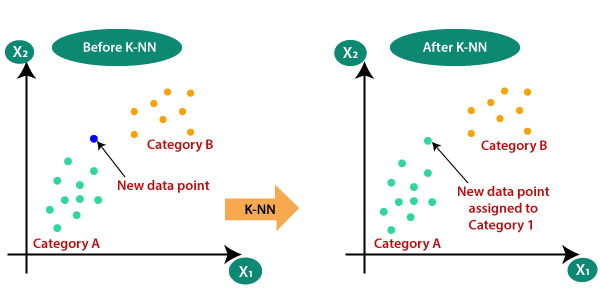

In [ ]:
import numpy as np

def NN1(traindata, trainlabel, query):
    """
    Predict label for a single query using 1-NN
    """
    # Compute squared Euclidean distance
    dist = np.sum((traindata - query) ** 2, axis=1)

    # Find index of nearest point
    idx = np.argmin(dist)

    # Return corresponding label
    return trainlabel[idx]


def NN(traindata, trainlabel, testdata):
    """
    Predict labels for multiple test samples using 1-NN
    """
    predlabel = np.array([NN1(traindata, trainlabel, x) for x in testdata])
    return predlabel

We will also define a 'random classifier', which randomly allots labels to each sample

In [ ]:
def RandomClassifier(traindata, trainlabel, testdata):
    """
    Random baseline classifier/regressor.
    Predicts random labels from training labels.
    """

    # Randomly select labels from training data
    predlabel = rng.choice(trainlabel, size=len(testdata))

    return predlabel

We need a metric to evaluate the performance of the model. Let us define a metric 'Accuracy' to see how good our learning algorithm is. Accuracy is the ratio of the number of correctly classified samples to the total number of samples. The higher the accuracy, the better the algorithm. We will use the accuracy metric to evaluate and compate the performance of the K-Nearest Neighbors model and the random classifier.

In [ ]:
def Accuracy(gtlabel, predlabel):
    """
    Compute accuracy for classification tasks
    """

    assert len(gtlabel) == len(predlabel), \
        "Length of labels must match"

    if len(gtlabel) == 0:
        return 0

    correct = np.sum(gtlabel == predlabel)

    return correct / len(gtlabel)

Let us make a function to split the dataset with the desired probability. We will use this function to split the dataset into training and testing sets. We will use the training set to train the model and the testing set to evaluate the model.

In [ ]:
def split(data, label, percent):
    """
    Split dataset into train and test sets
    """

    assert 0 < percent < 1, "percent must be between 0 and 1"

    # Shuffle indices
    indices = rng.permutation(len(label))
    cut = int(percent * len(label))

    train_idx = indices[:cut]
    test_idx = indices[cut:]

    X_train = data[train_idx]
    y_train = label[train_idx]
    X_test = data[test_idx]
    y_test = label[test_idx]

    return X_train, y_train, X_test, y_test

We will reserve 20% of our dataset as the test set. We will not change this portion throughout our experiments

In [ ]:
train_data, train_label, test_data, test_label = split(
    housing.data, housing.target, 0.8
)

print("Number of train samples:", len(train_label))
print("Number of test samples:", len(test_label))

percent = len(test_label) * 100 / len(housing.target)
print(f"Percent of test data: {percent:.2f}%")

Number of train samples: 16512
Number of test samples: 4128
Percent of test data: 20.00%


## Experiments with splits

Let us reserve some of our train data as a validation set

In [ ]:
traindata, trainlabel, valdata, vallabel = split(
    train_data, train_label, 0.75
)

print("Train samples:", len(trainlabel))
print("Validation samples:", len(vallabel))

Train samples: 12384
Validation samples: 4128


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


def evaluate_regression(true_values, pred_values):
    """
    Calculate and print regression metrics

    true_values: actual target values
    pred_values: predicted target values

    returns: MAE, MSE, RMSE
    """

    # Convert to numpy arrays (safety)
    true_values = np.array(true_values)
    pred_values = np.array(pred_values)

    # Calculate metrics
    mae = mean_absolute_error(true_values, pred_values)
    mse = mean_squared_error(true_values, pred_values)
    rmse = np.sqrt(mse)

    # Print results
    print("=== Regression Metrics ===")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

    return mae, mse, rmse


# ===============================
# Evaluate on Validation Set
# ===============================

# Predict using Nearest Neighbor
valpred = NN(traindata, trainlabel, valdata)

# Evaluate predictions
evaluate_regression(vallabel, valpred)

=== Regression Metrics ===
MAE:  0.9600
MSE:  1.6509
RMSE: 1.2849


(0.9600307000968993, 1.6509094566829698, np.float64(1.2848772146329663))

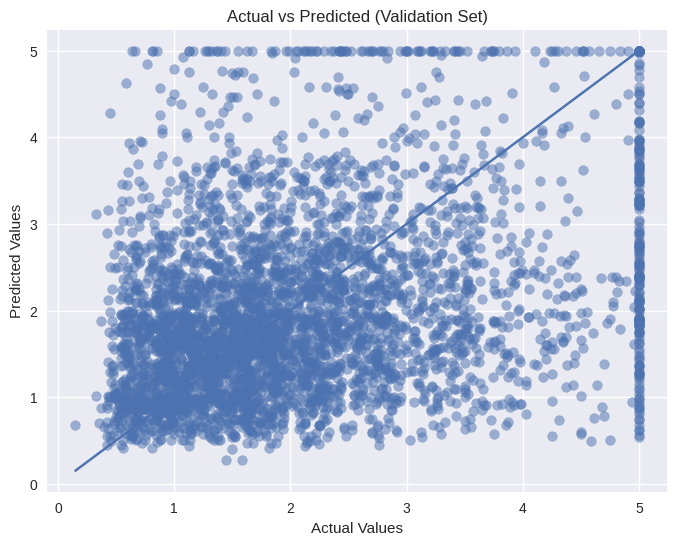

In [ ]:
import matplotlib.pyplot as plt

# Predict
valpred = NN(traindata, trainlabel, valdata)

# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(vallabel, valpred, alpha=0.5)

# Perfect prediction line
plt.plot([min(vallabel), max(vallabel)],
         [min(vallabel), max(vallabel)])

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Validation Set)")
plt.show()

What is the accuracy of our classifiers on the train dataset?

In [ ]:
# Nearest Neighbor on training data
nn_pred = NN(traindata, trainlabel, traindata)
nn_acc = Accuracy(trainlabel, nn_pred)

print(f"Training accuracy using NN: {nn_acc*100:.2f}% (overfitting expected)")

# Random Classifier on training data
rand_pred = RandomClassifier(traindata, trainlabel, traindata)
rand_acc = Accuracy(trainlabel, rand_pred)

print(f"Training accuracy using Random Classifier: {rand_acc*100:.2f}%")

Training accuracy using NN: 100.00% (overfitting expected)
Training accuracy using Random Classifier: 0.20%


For nearest neighbour, the train accuracy is always 1. The accuracy of the random classifier is close to 1/(number of classes) which is 0.1666 in our case. This is because the random classifier randomly assigns a label to each sample and the probability of assigning the correct label is 1/(number of classes). Let us predict the labels for our validation set and get the accuracy. This accuracy is a good estimate of the accuracy of our model on unseen data.

In [ ]:
# Nearest Neighbor on validation data
nn_val_pred = NN(traindata, trainlabel, valdata)

print("=== NN Validation Performance ===")
evaluate_regression(vallabel, nn_val_pred)


# Random Classifier on validation data
rand_val_pred = RandomClassifier(traindata, trainlabel, valdata)

print("\n=== Random Classifier Validation Performance ===")
evaluate_regression(vallabel, rand_val_pred)

=== NN Validation Performance ===
=== Regression Metrics ===
MAE:  0.9600
MSE:  1.6509
RMSE: 1.2849

=== Random Classifier Validation Performance ===
=== Regression Metrics ===
MAE:  1.2573
MSE:  2.6439
RMSE: 1.6260


(1.2573335125968994, 2.6438667240303775, np.float64(1.6259971476083153))

Validation accuracy of nearest neighbour is considerably less than its train accuracy while the validation accuracy of random classifier is the same. However, the validation accuracy of nearest neighbour is twice that of the random classifier. Now let us try another random split and check the validation accuracy. We will see that the validation accuracy changes with the split. This is because the validation set is small and the accuracy is highly dependent on the samples in the validation set. We can get a better estimate of the accuracy by using cross-validation.

In [ ]:
# Split train into train + validation
traindata, trainlabel, valdata, vallabel = split(
    train_data, train_label, 0.75
)

# Predict
valpred = NN(traindata, trainlabel, valdata)

# Evaluate using regression metrics
print("=== Validation Performance (NN) ===")
evaluate_regression(vallabel, valpred)

=== Validation Performance (NN) ===
=== Regression Metrics ===
MAE:  0.9601
MSE:  1.6371
RMSE: 1.2795


(0.9600938953488373, 1.6370879762126935, np.float64(1.2794873880631623))

You can run the above cell multiple times to try with different random splits.
We notice that the accuracy is different for each run, but close together.

Now let us compare it with the accuracy we get on the test dataset.

In [ ]:
# Predict on test data
testpred = NN(train_data, train_label, test_data)

# Evaluate using regression metrics
print("=== Test Performance (NN) ===")
evaluate_regression(test_label, testpred)

=== Test Performance (NN) ===
=== Regression Metrics ===
MAE:  0.9284
MSE:  1.5434
RMSE: 1.2423


(0.9284029651162791, 1.5433708705679263, np.float64(1.2423247846549332))

### Try it out for yourself and answer:
1. How is the accuracy of the validation set affected if we increase the percentage of validation set? What happens when we reduce it?
2. How does the size of the train and validation set affect how well we can predict the accuracy on the test set using the validation set?
3. What do you think is a good percentage to reserve for the validation set so that thest two factors are balanced?

Answer for both nearest neighbour and random classifier. You can note down the values for your experiments and plot a graph using  <a href=https://matplotlib.org/stable/gallery/lines_bars_and_markers/step_demo.html#sphx-glr-gallery-lines-bars-and-markers-step-demo-py>plt.plot<href>. Check also for extreme values for splits, like 99.9% or 0.1%

Q1 Answer:

Increasing validation size reduces training data, causing validation accuracy (for NN) to decrease. Reducing validation size improves training performance but makes validation results less reliable. For random classifier, accuracy remains almost constant.

Q2 Answer:

A small validation set gives unreliable estimates of test accuracy, while a large validation set reduces training data and weakens the model. Hence, both affect prediction quality.

Q3 Answer:

A validation size of around 20–30% is ideal to balance training performance and reliable evaluation.

> Exercise: Try to implement a 3 nearest neighbour classifier and compare the accuracy of the 1 nearest neighbour classifier and the 3 nearest neighbour classifier on the test dataset. You can use the KNeighborsClassifier class from the scikit-learn library to implement the K-Nearest Neighbors model. You can set the number of neighbors using the n_neighbors parameter. You can also use the accuracy_score function from the scikit-learn library to calculate the accuracy of the model.

Train samples: 16512
Test samples: 4128

Accuracy of 1-NN: 70.28%
Accuracy of 3-NN: 73.11%


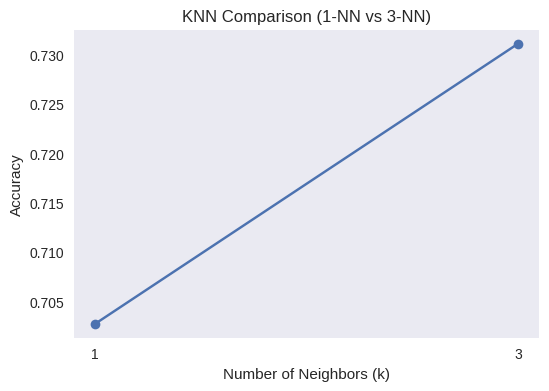

In [ ]:
# ===============================
# 1. IMPORTS
# ===============================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Random generator
rng = np.random.default_rng(seed=42)


# ===============================
# 2. LOAD DATASET
# ===============================
dataset = fetch_california_housing()

X = dataset.data
y = dataset.target


# ===============================
# 3. SPLIT FUNCTION
# ===============================
def split(data, label, percent):
    indices = rng.permutation(len(label))
    cut = int(percent * len(label))

    train_idx = indices[:cut]
    test_idx = indices[cut:]

    return data[train_idx], label[train_idx], data[test_idx], label[test_idx]


# ===============================
# 4. TRAIN-TEST SPLIT (80-20)
# ===============================
train_data, train_label, test_data, test_label = split(X, y, 0.8)

print("Train samples:", len(train_label))
print("Test samples:", len(test_label))


# ===============================
# 5. MANUAL 1-NN (OPTIONAL)
# ===============================
def NN1(traindata, trainlabel, query):
    dist = np.sum((traindata - query) ** 2, axis=1)
    return trainlabel[np.argmin(dist)]


def NN(traindata, trainlabel, testdata):
    return np.array([NN1(traindata, trainlabel, x) for x in testdata])


# ===============================
# 6. CONVERT TO CLASSIFICATION
# ===============================
# Convert continuous values to binary classes
train_label_cls = (train_label > 2.5).astype(int)
test_label_cls = (test_label > 2.5).astype(int)


# ===============================
# 7. 1-NN USING SKLEARN
# ===============================
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(train_data, train_label_cls)

pred1 = knn1.predict(test_data)
acc1 = accuracy_score(test_label_cls, pred1)

print(f"\nAccuracy of 1-NN: {acc1*100:.2f}%")


# ===============================
# 8. 3-NN USING SKLEARN
# ===============================
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(train_data, train_label_cls)

pred3 = knn3.predict(test_data)
acc3 = accuracy_score(test_label_cls, pred3)

print(f"Accuracy of 3-NN: {acc3*100:.2f}%")


# ===============================
# 9. COMPARISON GRAPH
# ===============================
k_values = [1, 3]
accuracies = [acc1, acc3]

plt.figure(figsize=(6, 4))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN Comparison (1-NN vs 3-NN)")
plt.xticks(k_values)
plt.grid()
plt.show()

## Multiple Splits

One way to get more accurate estimates for the test accuracy is by using <b>cross-validation</b>. Here, we will try a simple version, where we do multiple train/val splits and take the average of validation accuracies as the test accuracy estimation. Here is a function for doing this. Note that this function will take a long time to execute. You can reduce the number of splits to make it faster.

In [ ]:
import numpy as np

def AverageMAE(alldata, alllabel, splitpercent, iterations, model=NN):
    """
    Computes average MAE over multiple random splits

    alldata: feature data
    alllabel: target values
    splitpercent: training percentage (e.g., 0.8)
    iterations: number of repetitions
    model: prediction function (default NN)

    returns: average MAE
    """

    assert 0 < splitpercent < 1, "splitpercent must be between 0 and 1"
    assert iterations > 0, "iterations must be positive"

    total_mae = 0

    for _ in range(iterations):
        traindata, trainlabel, valdata, vallabel = split(
            alldata, alllabel, splitpercent
        )

        valpred = model(traindata, trainlabel, valdata)

        # MAE calculation
        mae = np.mean(np.abs(vallabel - valpred))
        total_mae += mae

    return total_mae / iterations

In [ ]:
# Average MAE over multiple splits
avg_mae = AverageMAE(train_data, train_label, 0.75, 10)
print(f"Average validation MAE: {avg_mae:.4f}")

# Test prediction
testpred = NN(train_data, train_label, test_data)

print("=== Test Performance ===")
evaluate_regression(test_label, testpred)

Average validation MAE: 0.9652
=== Test Performance ===
=== Regression Metrics ===
MAE:  0.9284
MSE:  1.5434
RMSE: 1.2423


(0.9284029651162791, 1.5433708705679263, np.float64(1.2423247846549332))

This is a very simple way of doing cross-validation. There are many well-known algorithms for cross-validation, like k-fold cross-validation, leave-one-out etc. This will be covered in detail in a later module. For more information about cross-validation, check <a href=https://en.wikipedia.org/wiki/Cross-validation_(statistics)>Cross-validatioin (Wikipedia)</a>

### Questions
1. Does averaging the validation accuracy across multiple splits give more consistent results?
2. Does it give more accurate estimate of test accuracy?
3. What is the effect of the number of iterations on the estimate? Do we get a better estimate with higher iterations?
4. Consider the results you got for the previous questions. Can we deal with a very small train dataset or validation dataset by increasing the iterations?


Q1 Answer:
Yes, averaging validation accuracy across multiple random splits gives more consistent results.

Q2 Answer:
Yes, it provides a better estimate of test accuracy compared to a single split.

Q3 Answer:
Increasing the number of iterations improves the estimate up to a certain point.

Q4 Answer:
No, increasing iterations cannot compensate for very small training or validation datasets.

> Exercise: How does the accuracy of the 3 nearest neighbour classifier change with the number of splits? How is it affected by the split size? Compare the results with the 1 nearest neighbour classifier.

Exercise Answer: The accuracy of the 3-nearest neighbour classifier becomes more stable as the number of splits (iterations) increases, since averaging over multiple splits reduces randomness. The accuracy is also affected by the split size: increasing the training set size improves accuracy, while increasing the validation set size reduces training data and lowers accuracy. When compared to the 1-nearest neighbour classifier, the 3-nearest neighbour classifier performs better because it considers multiple neighbours, reducing overfitting and improving generalization.